Problem 2

Part (b)

In [2]:
import numpy as np

def p(n,a,K):
    return K*np.exp(a*n)

def q(n,b,K):
    return K*np.exp(b*(n-1))

a = 0.04
b = 0.16
K = 0.1
main = np.array([
    1 - p(i,a,K) - q(i,b,K) if 1 < i < 5
    else (1 - p(i,a,K) if i == 1
          else 1 - q(i,b,K))
    for i in range(1, 5+1)
])
upper = np.array([p(i,a,K) for i in range(1, 5)])
lower = np.array([q(i,b,K) for i in range(2, 6)])

A = np.diag(main) + np.diag(upper, k=1) + np.diag(lower, k=-1)
print(A)

def power_method_markov(A, max_iter=10000, tol=1e-12):
    n = A.shape[0]

    x = np.random.rand(n)
    x /= np.sum(x)

    for k in range(max_iter):
        y = A @ x
        x_new = y / np.sum(y)

        if np.linalg.norm(x_new - x, 1) < tol:
            break

        x = x_new

    return 1.0, x, k+1

lam, pi, iters = power_method_markov(A.T)
print(lam, pi)

[[0.89591892 0.10408108 0.         0.         0.        ]
 [0.11735109 0.77432021 0.10832871 0.         0.        ]
 [0.         0.13771278 0.74953754 0.11274969 0.        ]
 [0.         0.         0.16160744 0.72104147 0.11735109]
 [0.         0.         0.         0.18964809 0.81035191]]
1.0 [0.29651214 0.26298267 0.2068695  0.14432795 0.08930774]


Part (c)

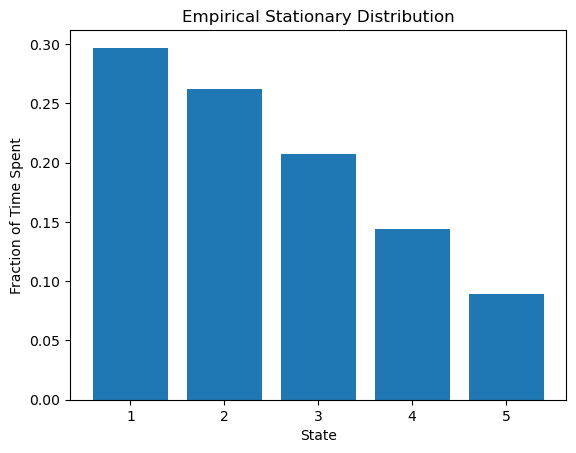

In [3]:
import matplotlib.pyplot as plt

rng = np.random.default_rng()
state = 0  # start at state 1
counts = np.zeros(5)

for _ in range(10**6):
    counts[state] += 1
    state = rng.choice(5, p=A[state])

empirical_pi = counts / 10**6

plt.figure()
plt.bar(range(1, 6), empirical_pi)
plt.xlabel("State")
plt.ylabel("Fraction of Time Spent")
plt.title("Empirical Stationary Distribution")
plt.show()

Part (d)

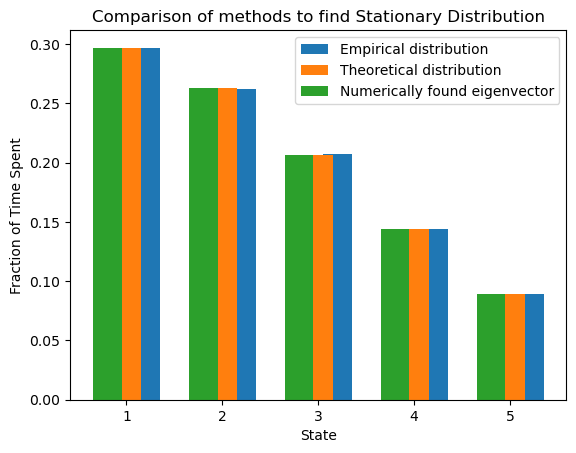

In [4]:
def theo_pi(a,b,n):
    return np.exp((a-b)*n*(n-1)/2) / np.sum([np.exp((a-b)*n*(n-1)/2) for n in range(1,6)])

theoretical_pi = np.array([theo_pi(a,b,i) for i in range(1,6)])

plt.figure()
plt.bar(np.arange(1,6)+.2, empirical_pi, label="Empirical distribution", width=0.3)
plt.bar(np.arange(1,6), theoretical_pi, label="Theoretical distribution", width=0.3)
plt.bar(np.arange(1,6)-.2, pi, label="Numerically found eigenvector", width=0.3)
plt.xlabel("State")
plt.ylabel("Fraction of Time Spent")
plt.title("Comparison of methods to find Stationary Distribution")
plt.legend()
plt.show()

Problem 3

Part (b)

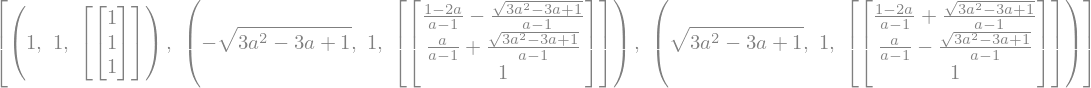

In [5]:
import sympy as sp
a = sp.symbols("a")
A = sp.Matrix([[1-a, a, 0], [a, 0, 1-a], [0, 1-a, a]])

sp.init_printing()
(A.T).eigenvects()

Part (c)

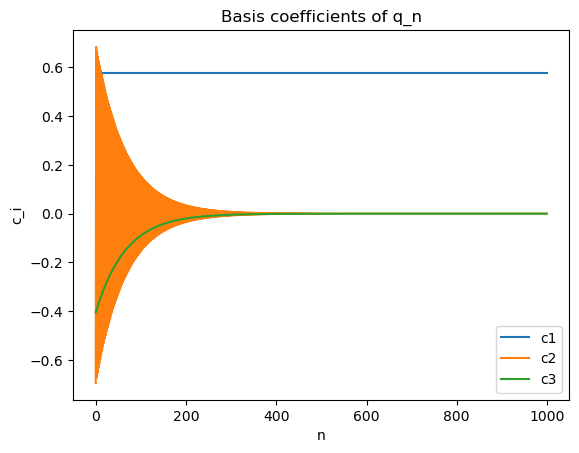

In [ ]:
a = 0.99

A = np.array([[1-a, a, 0], [a, 0, 1-a],[0, 1-a, a]])

evals, evecs = np.linalg.eig(A.T)

idx = np.argsort(np.abs(evals))[::-1]
evals = evals[idx]
evecs = evecs[:, idx]
q = np.array([1-a, a, 0])

coeffs = []
for _ in range(1000):
    coeff = np.dot(q,evecs)
    coeffs.append(coeff)
    q = A @ q

coeffs = np.array(coeffs)


plt.plot(coeffs[:,0], label="c1")
plt.plot(coeffs[:,1], label="c2")
plt.plot(coeffs[:,2], label="c3")
plt.title("Basis coefficients of q_n")
plt.xlabel("n")
plt.ylabel("c_i")
plt.legend()
plt.show()

The first basis coefficient stays constant, which is the one corresponding to the stationary distribution (eigenvector with eigenvalue 1). The other two coefficients are decaying exponentially. The second one is oscillating but still exponential

Part (e)

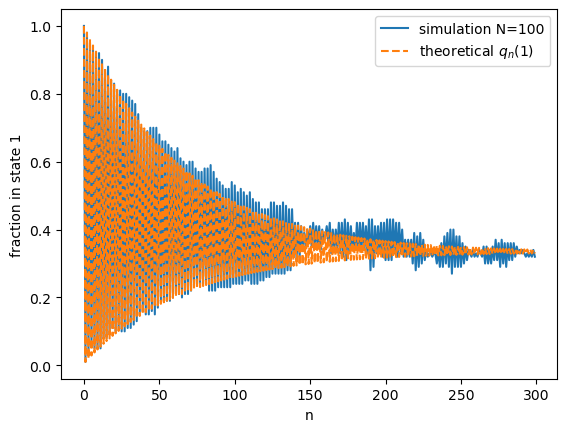

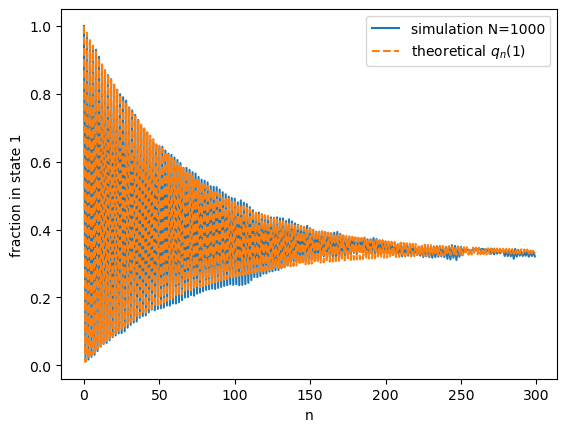

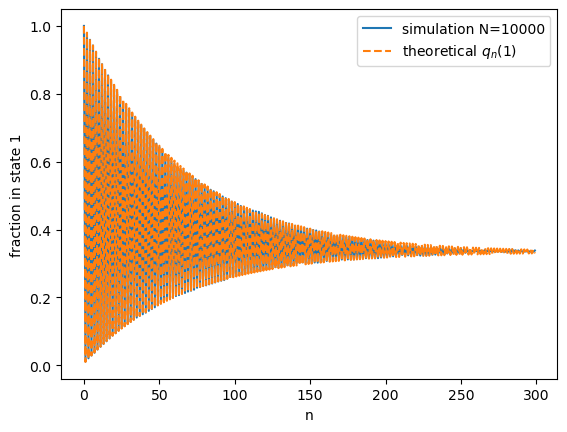

In [10]:
steps = 300

for N in [100, 1000, 10000]:

    states = np.zeros(N, dtype=int)
    fn = []

    for n in range(steps):

        fn.append(np.mean(states == 0))

        new_states = np.zeros_like(states)
        for i in range(N):
            new_states[i] = np.random.choice(3, p=A[states[i]])

        states = new_states

    fn = np.array(fn)

    q = np.array([1,0,0], dtype=float)

    theory = []
    for _ in range(steps):
        theory.append(q[0])
        q = A @ q
    theory = np.array(theory)


    plt.figure()
    plt.plot(fn, label=f"simulation N={N}")
    plt.plot(theory, "--", label="theoretical $q_n(1)$")
    plt.xlabel("n")
    plt.ylabel("fraction in state 1")
    plt.legend()
    plt.show()